# Spatial Domain Filters

### Box Filter → smooths with equal weights.

### Gaussian Filter → smooths but gives higher weight to center.

### Median Filter → replaces pixel with median of neighborhood.

### Min Filter → keeps darkest value (erosion).

### Max Filter → keeps brightest value (dilation).

### Opening → removes small white noise.

### Closing → fills small black holes.

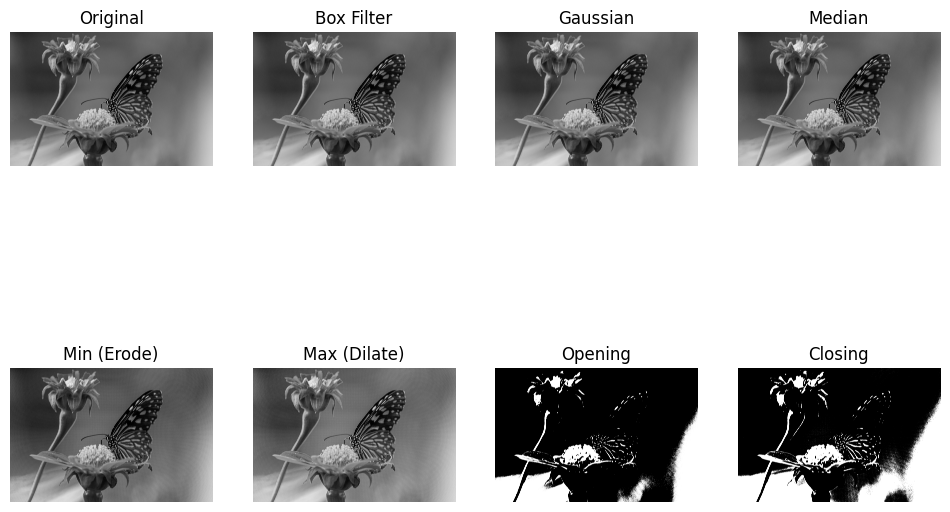

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load image in grayscale
img = cv2.imread("img.jpg", 0)

# ---------- Linear Filters ----------
# 1. Box Filter (Mean Filter)
box_filter = cv2.blur(img, (3, 3))   # 3x3 averaging

# 2. Weighted Filter (Gaussian Filter)
gaussian_filter = cv2.GaussianBlur(img, (5, 5), 1)  # 5x5 kernel, sigma=1

# ---------- Non-Linear Filters ----------
# 3. Median Filter
median_filter = cv2.medianBlur(img, 3)   # 3x3 window

# 4. Min Filter (Erode = min operation)
kernel = np.ones((3, 3), np.uint8)
min_filter = cv2.erode(img, kernel)

# 5. Max Filter (Dilate = max operation)
max_filter = cv2.dilate(img, kernel)

# ---------- Morphological Filters ----------
# For morphological filters, we usually work with binary images
_, binary_img = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# 6. Opening = Erosion followed by Dilation
opening = cv2.morphologyEx(binary_img, cv2.MORPH_OPEN, kernel)

# 7. Closing = Dilation followed by Erosion
closing = cv2.morphologyEx(binary_img, cv2.MORPH_CLOSE, kernel)

# ---------- Show Results ----------
titles = ['Original', 'Box Filter', 'Gaussian', 'Median',
          'Min (Erode)', 'Max (Dilate)', 'Opening', 'Closing']
images = [img, box_filter, gaussian_filter, median_filter,
          min_filter, max_filter, opening, closing]

plt.figure(figsize=(12, 8))
for i in range(len(images)):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()
